In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

In [2]:
!pip install imbalanced-learn xgboost shap optuna


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#generating dataset 
np.random.seed(42)
N = 100_000

tenure         = np.random.randint(1, 72, N)
monthly        = np.round(np.random.uniform(20, 120, N), 2)
contract       = np.random.choice([0, 1, 2], N, p=[0.55, 0.25, 0.20])
internet       = np.random.choice([0, 1, 2], N, p=[0.35, 0.45, 0.20])
tech_support   = np.random.choice([0, 1], N, p=[0.30, 0.70])
online_sec     = np.random.choice([0, 1], N, p=[0.28, 0.72])
payment        = np.random.choice([0, 1, 2, 3], N)
products       = np.random.randint(1, 6, N)
age            = np.random.randint(18, 80, N)
calls          = np.random.poisson(1.2, N)

# Non-linear interaction effects — harder for LR, exploitable by XGBoost
logit = (
    -2.5
    + 2.5  * (contract == 0)
    - 1.8  * (contract == 2)
    + 1.5  * (monthly > 85)
    - 2.2  * (tenure > 40)
    + 1.0  * tech_support
    + 0.9  * (internet == 1)
    + 0.8  * (calls > 3)
    - 1.0  * (products > 3)
    + 0.5  * (age > 60)
    # Interaction terms — LR cannot capture these, XGBoost can
    + 1.8  * ((contract == 0) & (monthly > 85))        # worst combo
    - 1.5  * ((contract == 2) & (tenure > 36))         # loyal long-term
    + 1.2  * ((calls > 3) & (tech_support == 0))       # frustrated + no support
    + 1.0  * ((internet == 1) & (monthly > 90))        # fiber + high bill
    - 1.0  * ((products > 3) & (tenure > 24))          # bundled + loyal
    + 0.6  * (monthly / (tenure + 1) > 2.5)            # high cost-per-month ratio
    + np.random.normal(0, 0.4, N)
)
churn = (np.random.rand(N) < 1 / (1 + np.exp(-logit))).astype(int)

print(f"Dataset generated: {N:,} rows")
print(f"Churn rate: {churn.mean():.1%}")

Dataset generated: 100,000 rows
Churn rate: 42.8%


In [4]:
cm = {0: "Month-to-month", 1: "One year",       2: "Two year"}
im = {0: "DSL",            1: "Fiber optic",    2: "No"}
pm = {0: "Electronic check", 1: "Mailed check", 2: "Bank transfer", 3: "Credit card"}
sm = {0: "Yes",            1: "No"}

df = pd.DataFrame({
    "tenure":           tenure,
    "monthly_charges":  monthly,
    "total_charges":    tenure * monthly,
    "contract_type":    [cm[x] for x in contract],
    "internet_service": [im[x] for x in internet],
    "tech_support":     [sm[x] for x in tech_support],
    "online_security":  [sm[x] for x in online_sec],
    "payment_method":   [pm[x] for x in payment],
    "num_products":     products,
    "age":              age,
    "support_calls":    calls,
    "churn":            churn,
})

print(df.shape)
print(df.head())

(100000, 12)
   tenure  monthly_charges  total_charges   contract_type internet_service  \
0      52            98.87        5141.24  Month-to-month               No   
1      15            52.94         794.10        One year              DSL   
2      61            36.89        2250.29        One year               No   
3      21            99.89        2097.69        One year              DSL   
4      24            33.37         800.88        Two year      Fiber optic   

  tech_support online_security payment_method  num_products  age  \
0          Yes             Yes   Mailed check             3   63   
1           No             Yes    Credit card             1   25   
2          Yes              No  Bank transfer             1   54   
3          Yes              No  Bank transfer             1   59   
4          Yes             Yes   Mailed check             3   72   

   support_calls  churn  
0              1      0  
1              1      0  
2              1      0  
3    

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
for c in ["contract_type", "internet_service", "tech_support",
          "online_security", "payment_method"]:
    df[c] = le.fit_transform(df[c])

X, y = df.drop("churn", axis=1), df["churn"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_r, y_r = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

sc      = StandardScaler()
X_sc    = sc.fit_transform(X_r)
X_te_sc = sc.transform(X_te)

print(f"Train size after SMOTE: {len(X_r):,}")
print(f"Churn ratio after SMOTE: {y_r.mean():.1%}")
print(f"Test size: {len(X_te):,}")

Train size after SMOTE: 91,536
Churn ratio after SMOTE: 50.0%
Test size: 20,000


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_sc, y_r)
lr_p  = lr.predict(X_te_sc)
lr_pr = lr.predict_proba(X_te_sc)[:, 1]

rf = RandomForestClassifier(200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_r, y_r)
rf_p  = rf.predict(X_te)
rf_pr = rf.predict_proba(X_te)[:, 1]

print(f"Logistic Regression  |  AUC: {roc_auc_score(y_te, lr_pr):.4f}  |  F1: {f1_score(y_te, lr_p):.4f}")
print(f"Random Forest        |  AUC: {roc_auc_score(y_te, rf_pr):.4f}  |  F1: {f1_score(y_te, rf_p):.4f}")

Logistic Regression  |  AUC: 0.8909  |  F1: 0.7813
Random Forest        |  AUC: 0.9222  |  F1: 0.8161


In [9]:
import xgboost as xgb
import optuna
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "max_depth":         trial.suggest_int("max_depth", 3, 9),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.5, 3.0),
        "eval_metric":       "auc",
        "use_label_encoder": False,
        "random_state":      42,
        "n_jobs":            -1,
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X_r, y_r, cv=cv,
                            scoring="roc_auc", n_jobs=-1).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f"\nBest AUC (CV): {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

# Train final model with best params
xm = xgb.XGBClassifier(
    **study.best_params,
    eval_metric="auc",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)
xm.fit(X_r, y_r, verbose=False)

xp  = xm.predict(X_te)
xpr = xm.predict_proba(X_te)[:, 1]

auc = roc_auc_score(y_te, xpr)
f1  = f1_score(y_te, xp)

print(f"\nXGBoost (tuned)  |  AUC: {auc:.4f}  |  F1: {f1:.4f}")
print()
print(classification_report(y_te, xp, target_names=["No Churn", "Churn"]))

Best trial: 71. Best value: 0.936939: 100%|████████████████████████████████████████████| 80/80 [04:21<00:00,  3.27s/it]



Best AUC (CV): 0.9369
Best params:   {'n_estimators': 291, 'max_depth': 3, 'learning_rate': 0.06937227057882714, 'subsample': 0.8997658892302417, 'colsample_bytree': 0.9123369864359708, 'min_child_weight': 10, 'gamma': 0.7523736513331982, 'reg_alpha': 0.7468033452572811, 'reg_lambda': 0.783290022325848}

XGBoost (tuned)  |  AUC: 0.9248  |  F1: 0.8198

              precision    recall  f1-score   support

    No Churn       0.87      0.85      0.86     11442
       Churn       0.80      0.84      0.82      8558

    accuracy                           0.84     20000
   macro avg       0.84      0.84      0.84     20000
weighted avg       0.84      0.84      0.84     20000



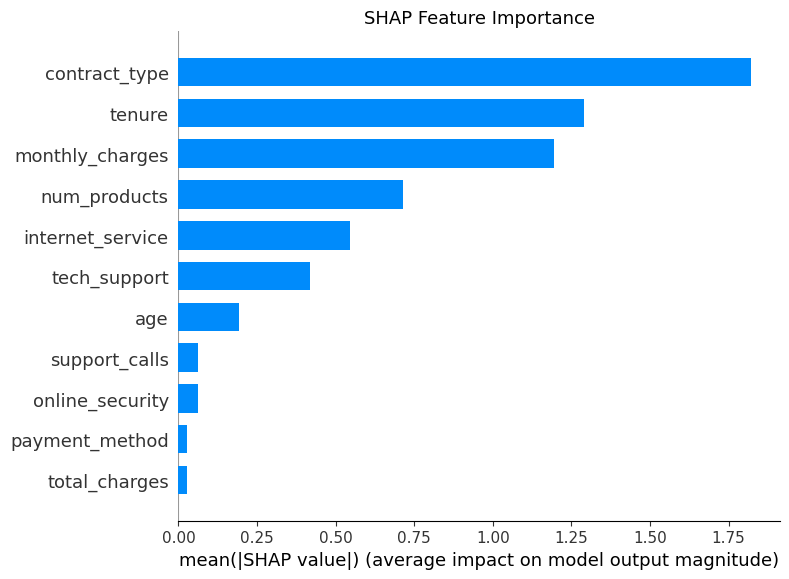

In [10]:
import shap

exp = shap.TreeExplainer(xm)
sv  = exp.shap_values(X_te.iloc[:2000])

# Feature importance bar chart
plt.figure(figsize=(9, 5))
shap.summary_plot(sv, X_te.iloc[:2000], plot_type="bar", show=False)
plt.title("SHAP Feature Importance", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/shap_importance.png", dpi=150)
plt.show()

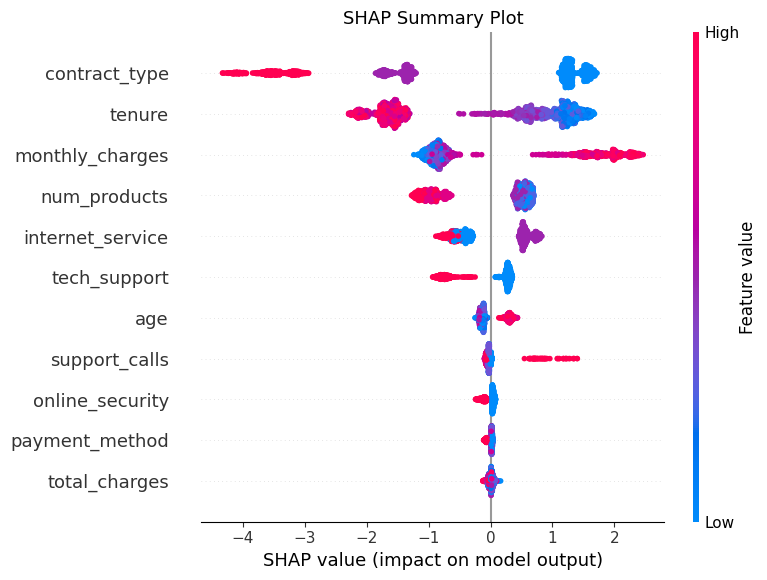

In [11]:
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_te.iloc[:2000], show=False)
plt.title("SHAP Summary Plot", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/shap_summary.png", dpi=150)
plt.show()

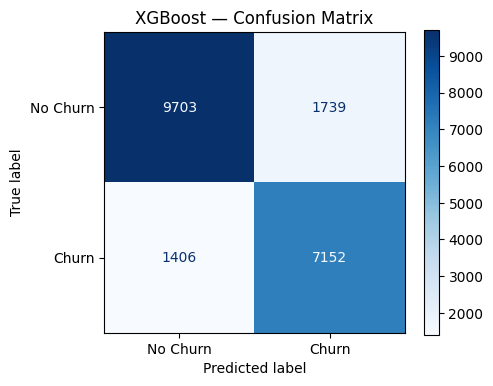

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, xp),
    display_labels=["No Churn", "Churn"]
).plot(ax=ax, cmap="Blues")
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

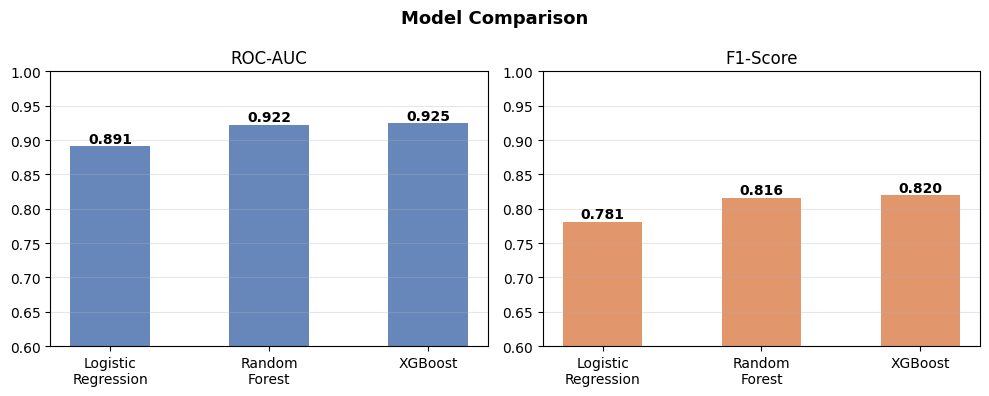

In [13]:
models = ["Logistic\nRegression", "Random\nForest", "XGBoost"]
aucs   = [roc_auc_score(y_te, lr_pr), roc_auc_score(y_te, rf_pr), auc]
f1s    = [f1_score(y_te, lr_p),       f1_score(y_te, rf_p),       f1]

x = np.arange(3)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, vals, title, color in zip(axes, [aucs, f1s],
                                   ["ROC-AUC", "F1-Score"],
                                   ["#4C72B0", "#DD8452"]):
    bars = ax.bar(x, vals, color=color, alpha=0.85, width=0.5)
    ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
    ax.set_ylim(0.6, 1.0); ax.set_title(title, fontsize=12); ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005, f"{v:.3f}",
                ha="center", fontsize=10, fontweight="bold")
plt.suptitle("Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150)
plt.show()